In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('../python_code').resolve()))
import numpy as np
import cv2
import csv
from scipy.stats import rankdata
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
from DataGenerator import HyperspectralTorchDataset
from ManualCNNClassifier import HyperspectralMultiCNN

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Infected/Tray_2_row_0_column_2.npy")
model_path = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds/Models/HyperspectralMultiCNN_1-92-183-274-365-456-547-638-bands-0.981-accuracy.pt")
seeds_root = Path("../home/ARO.local/collaboration/sagi-tomer-collab/Normalized_Tomato_Seeds")

# --- Infer Bands and Label ---
model_name = model_path.stem
bands_str = model_name.split("_")[1].split("-bands")[0]
bands = list(map(int, bands_str.split("-")))
label = 0 if "Healthy" in str(image_path) else 1
print(bands, label)

# --- Prepare Image ---
image = np.load(image_path)
height, width = image.shape[:2]
shape = (height, width, len(bands))

dataset = HyperspectralTorchDataset([str(image_path)], [label], bands, shape)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

for image, _ in loader:
    image = image.to(device)

[1, 92, 183, 274, 365, 456, 547, 638] 1


In [12]:
multi_cnn_model = HyperspectralMultiCNN(len(bands))

# Load the state dict
state = torch.load(model_path, map_location=device)

# Strip the prefix, if needed (for example, '_orig_mod.')
state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}

# Get current model state_dict
model_state = multi_cnn_model.state_dict()

# Update only the matching keys
for key in model_state.keys():
    if key in state and state[key].shape == model_state[key].shape:
        model_state[key] = state[key]  # Copy the matching weights

# Load the state_dict into the model
multi_cnn_model.load_state_dict(model_state)

# model = torch.compile(model, backend="eager")
multi_cnn_model.to(device).eval()

logits = multi_cnn_model(image)

print("prediction", logits.detach().numpy())

prediction [[-2.660535]]


C:\Users\sagig\AppData\Local\Temp\ipykernel_21876\3304391296.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location=device)


Patch at x=0, y=0 | Predicted class: 0 | Confidence: 0.92
Patch at x=17, y=0 | Predicted class: 0 | Confidence: 0.64
Patch at x=34, y=0 | Predicted class: 1 | Confidence: 0.65
Patch at x=51, y=0 | Predicted class: 1 | Confidence: 0.90
Patch at x=68, y=0 | Predicted class: 1 | Confidence: 0.58
Patch at x=0, y=12 | Predicted class: 0 | Confidence: 0.97
Patch at x=17, y=12 | Predicted class: 0 | Confidence: 0.85
Patch at x=34, y=12 | Predicted class: 0 | Confidence: 0.67
Patch at x=51, y=12 | Predicted class: 1 | Confidence: 0.99
Patch at x=68, y=12 | Predicted class: 1 | Confidence: 0.92
Patch at x=0, y=24 | Predicted class: 0 | Confidence: 0.99
Patch at x=17, y=24 | Predicted class: 0 | Confidence: 0.99
Patch at x=34, y=24 | Predicted class: 0 | Confidence: 0.99
Patch at x=51, y=24 | Predicted class: 1 | Confidence: 0.98
Patch at x=68, y=24 | Predicted class: 1 | Confidence: 0.92
Patch at x=0, y=36 | Predicted class: 0 | Confidence: 0.99
Patch at x=17, y=36 | Predicted class: 0 | Confid

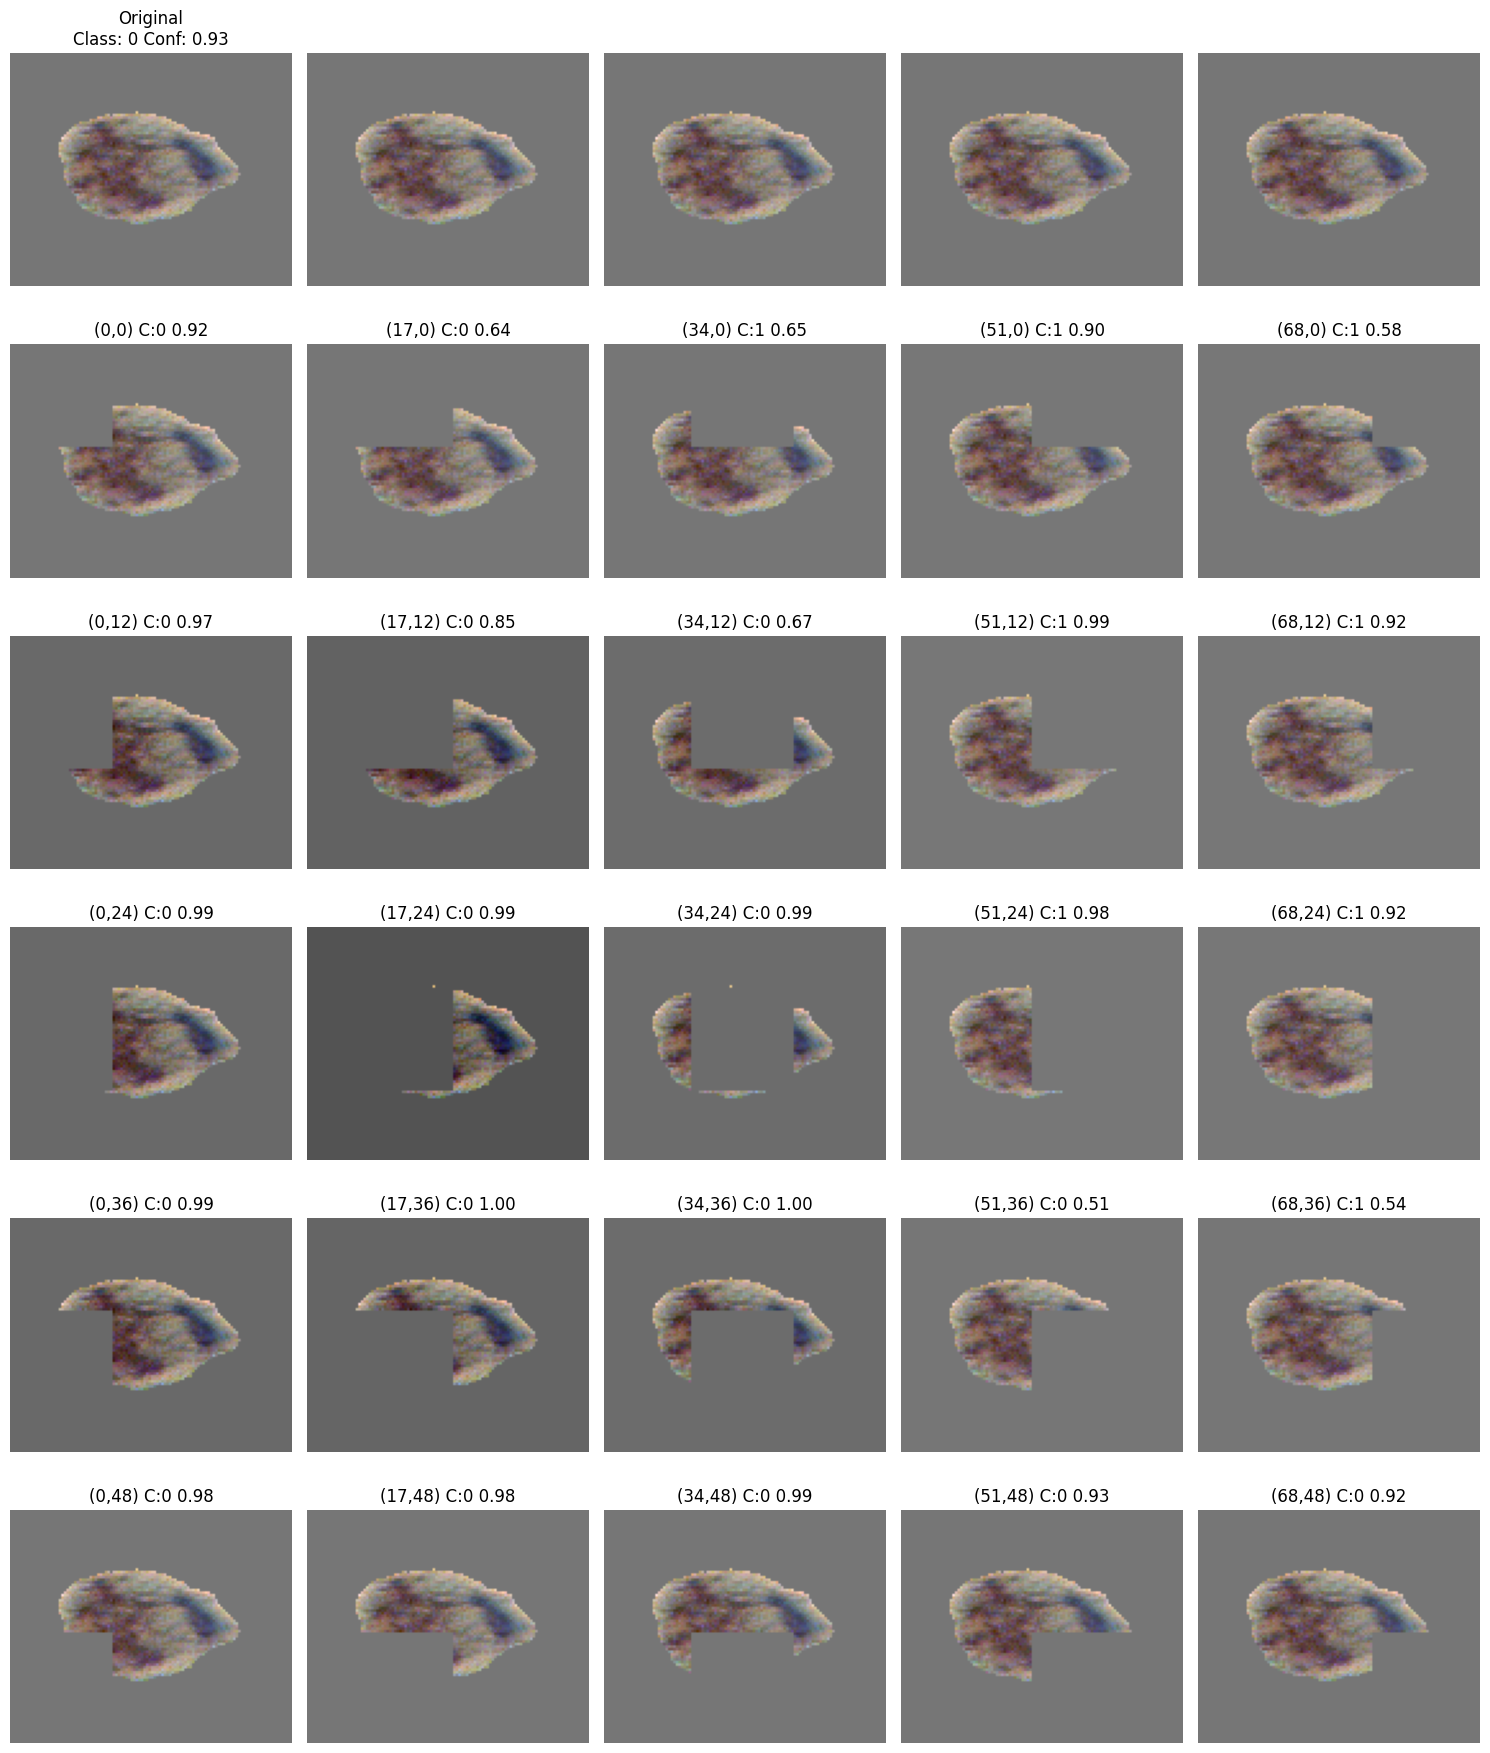

In [22]:
window_size = 40  # patch size
num_patches_x = 5
num_patches_y = 5
stride_x = (width - window_size) // (num_patches_x - 1)
stride_y = (height - window_size) // (num_patches_y - 1)

with torch.no_grad():
    original_logits = multi_cnn_model(image)
    prob_pos = torch.sigmoid(original_logits)[0].item()
    original_class = 1 if prob_pos > 0.5 else 0
    base_score = prob_pos if original_class == 1 else 1 - prob_pos

# Create grid with one extra row for the original image
fig, axes = plt.subplots(num_patches_y + 1, num_patches_x, figsize=(num_patches_x * 3, (num_patches_y + 1) * 3))

# Show original image on the first row (spanning all columns)
vis_img = image[0].cpu().numpy()
if vis_img.shape[0] > 3:
    vis_img = vis_img[:3]
vis_img = np.transpose(vis_img, (1, 2, 0))
vis_img = (vis_img - vis_img.min()) / (vis_img.max() - vis_img.min() + 1e-8)

for ax in axes[0]:
    ax.imshow(vis_img)
    ax.axis('off')
# axes[0, 0].set_title(f"Original\nClass: {original_class} Conf: {original_logits.detach().numpy()[0][0]:.2f}")
axes[0, 0].set_title(f"Original\nClass: {original_class} Conf: {base_score:.2f}")
# Hide other titles in first row
for ax in axes[0, 1:]:
    ax.set_title("")

for i, y in enumerate(range(0, height - window_size + 1, stride_y)):
    for j, x in enumerate(range(0, width - window_size + 1, stride_x)):
        occluded_image = image.clone()
        occluded_image[:, :, y:y+window_size, x:x+window_size] = 0

        with torch.no_grad():
            logits = multi_cnn_model(occluded_image)
            prob_pos = torch.sigmoid(logits)[0].item()
            pred_class = 1 if prob_pos > 0.5 else 0
            conf = prob_pos if pred_class == 1 else 1 - prob_pos

        print(f"Patch at x={x}, y={y} | Predicted class: {pred_class} | Confidence: {conf:.2f}")

        vis_img = occluded_image[0].cpu().numpy()
        if vis_img.shape[0] > 3:
            vis_img = vis_img[:3]
        vis_img = np.transpose(vis_img, (1, 2, 0))
        vis_img = (vis_img - vis_img.min()) / (vis_img.max() - vis_img.min() + 1e-8)

        ax = axes[i+1, j]  # +1 because row 0 is original
        ax.imshow(vis_img)
        # ax.set_title(f"({x},{y}) C:{pred_class} {logits.detach().numpy()[0][0]:.2f}")
        ax.set_title(f"({x},{y}) C:{pred_class} {conf:.2f}")
        ax.axis('off')

plt.tight_layout()
plt.show()